<a href="https://colab.research.google.com/github/thushanthasmitha/ARC-Prize-2026---ARC-AGI-3/blob/main/ARC_Prize_2026_ARC_AGI_3ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_9b10031ab644d61c3557d8ba9479a99e'

!mkdir -p ~/.kaggle
!echo "KGAT_9b10031ab644d61c3557d8ba9479a99e" > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

!kaggle competitions download -c arc-prize-2026-arc-agi-3
!mkdir -p arc_data
!unzip -q arc-prize-2026-arc-agi-3.zip -d arc_data

!ls arc_data

100% 42.3M/42.3M [00:00<00:00, 163MB/s]

ARC-AGI-3-Agents  arc_agi_3_wheels  environment_files


In [9]:
import json
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

# 1. Define standard ARC 10-color palette for professional visualization
# (0 = black/background, 1 = blue, 2 = red, etc.)
arc_colors = [
    '#000000', '#0074D9', '#FF4136', '#2ECC40', '#FFDC00',
    '#AAAAAA', '#F012BE', '#FF851B', '#7FDBFF', '#870000'
]
cmap = colors.ListedColormap(arc_colors)
norm = colors.Normalize(vmin=0, vmax=9)

# 2. Search for JSON task files inside the extracted directories
json_pattern = 'arc_data/ARC-AGI-3-Agents/**/*.json'
json_files = glob.glob(json_pattern, recursive=True)

# Fallback: Scan the entire arc_data folder if files are not found in the agents directory
if not json_files:
    json_files = glob.glob('arc_data/**/*.json', recursive=True)

if json_files:
    print(f"Total number of puzzles (JSON files) found: {len(json_files)}")
    example_file = json_files[0] # Selecting the first puzzle as a sample reference
    print(f"Currently displaying task file: {example_file}")

    with open(example_file, 'r') as f:
        task = json.load(f)

    # Check if 'train' key exists, as metadata files might not have it
    if 'train' in task:
        # 3. Plot the training input-output pairs to evaluate underlying patterns
        num_train = len(task['train'])
        fig, axs = plt.subplots(num_train, 2, figsize=(10, num_train * 4))

        # Handle single training pair edge case to keep axs array indexable
        if num_train == 1:
            axs = np.expand_dims(axs, axis=0)

        for i, sample in enumerate(task['train']):
            # Render and format the Input Grid
            in_grid = np.array(sample['input'])
            axs[i, 0].imshow(in_grid, cmap=cmap, norm=norm)
            axs[i, 0].grid(True, which='both', color='#555555', linestyle='-', linewidth=0.7)
            axs[i, 0].set_title(f"Train {i+1} - Input {in_grid.shape}")
            axs[i, 0].set_xticks(np.arange(-.5, in_grid.shape[1], 1), minor=True)
            axs[i, 0].set_yticks(np.arange(-.5, in_grid.shape[0], 1), minor=True)

            # Render and format the Output Grid
            out_grid = np.array(sample['output'])
            axs[i, 1].imshow(out_grid, cmap=cmap, norm=norm)
            axs[i, 1].grid(True, which='both', color='#555555', linestyle='-', linewidth=0.7)
            axs[i, 1].set_title(f"Train {i+1} - Output {out_grid.shape}")
            axs[i, 1].set_xticks(np.arange(-.5, out_grid.shape[1], 1), minor=True)
            axs[i, 1].set_yticks(np.arange(-.5, out_grid.shape[0], 1), minor=True)

        plt.tight_layout()
        plt.show()
    else:
        print(f"Warning: The file '{example_file}' does not contain a 'train' key.")
        print("This file appears to be a metadata file rather than an ARC task definition file.")
        print("ARC task files typically contain 'train' and 'test' keys with input/output grids for problem solving.")
        print("Please ensure you are loading a valid ARC task file.")
else:
    print("Error: No JSON task files detected. Please verify the internal directory structure under 'arc_data'.")

Total number of puzzles (JSON files) found: 25
Currently displaying task file: arc_data/environment_files/s5i5/18d95033/metadata.json
This file appears to be a metadata file rather than an ARC task definition file.
ARC task files typically contain 'train' and 'test' keys with input/output grids for problem solving.
Please ensure you are loading a valid ARC task file.


In [ ]:
import os

# Walk through the directory to find where the JSON files are hidden
for root, dirs, files_list in os.walk('arc_data'):
    # Check if there are any JSON files in the current folder
    json_in_dir = [f for f in files_list if f.endswith('.json')]
    if json_in_dir:
        print(f"Found JSON folder: {root} (Contains {len(json_in_dir)} files)")
        print(f"Sample file: {json_in_dir[0]}\n")

Found JSON folder: arc_data/environment_files/s5i5/18d95033 (Contains 1 files)
Sample file: metadata.json

Found JSON folder: arc_data/environment_files/r11l/495a7899 (Contains 1 files)
Sample file: metadata.json

Found JSON folder: arc_data/environment_files/vc33/5430563c (Contains 1 files)
Sample file: metadata.json

Found JSON folder: arc_data/environment_files/lp85/305b61c3 (Contains 1 files)
Sample file: metadata.json

Found JSON folder: arc_data/environment_files/ft09/0d8bbf25 (Contains 1 files)
Sample file: metadata.json

Found JSON folder: arc_data/environment_files/lf52/271a04aa (Contains 1 files)
Sample file: metadata.json

Found JSON folder: arc_data/environment_files/tr87/cd924810 (Contains 1 files)
Sample file: metadata.json

Found JSON folder: arc_data/environment_files/ka59/38d34dbb (Contains 1 files)
Sample file: metadata.json

Found JSON folder: arc_data/environment_files/cn04/2fe56bfb (Contains 1 files)
Sample file: metadata.json

Found JSON folder: arc_data/environme

In [ ]:
import json

# Let's inspect one of the metadata files to understand how tasks are structured
sample_metadata_path = 'arc_data/environment_files/tr87/cd924810/metadata.json'

with open(sample_metadata_path, 'r') as f:
    metadata = json.load(f)

# Print keys to see the structure
print("Metadata Keys:", metadata.keys())
print("-" * 50)
# Print a snippet of the content
print(json.dumps(metadata, indent=2)[:1000]) # Printing first 1000 characters

Metadata Keys: dict_keys(['game_id', 'title', 'default_fps', 'tags', 'baseline_actions', 'local_dir', 'date_downloaded'])
--------------------------------------------------
{
  "game_id": "tr87-cd924810",
  "title": "TR87",
  "default_fps": 10,
  "tags": [
    "keyboard"
  ],
  "baseline_actions": [
    54,
    58,
    40,
    45,
    71,
    146
  ],
  "local_dir": "environment_files/tr87/cd924810",
  "date_downloaded": "2026-04-08T20:07:48.580272+00:00"
}


Cloning into 'ARC'...
remote: Enumerating objects: 1277, done.
remote: Counting objects: 100% (284/284), done.
remote: Compressing objects: 100% (109/109), done.
remote: Total 1277 (delta 194), reused 175 (delta 175), pack-reused 993 (from 2)
Receiving objects: 100% (1277/1277), 499.69 KiB | 3.38 MiB/s, done.
Resolving deltas: 100% (727/727), done.
Successfully loaded 400 clean ARC puzzles for training!
Displaying Task File: caa06a1f.json


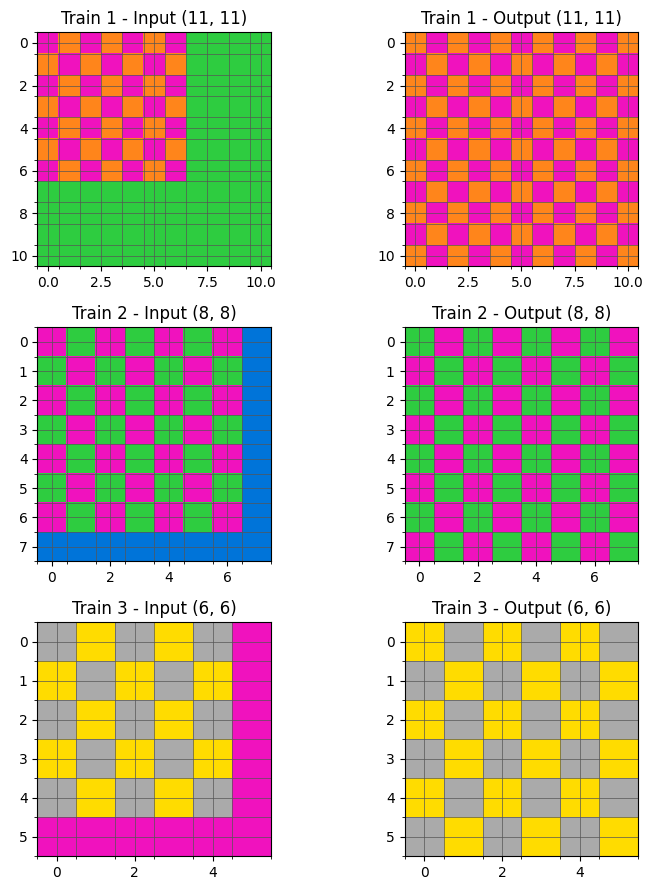

In [ ]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

# 1. Clone the official ARC repository to get the clean JSON tasks
if not os.path.exists('ARC'):
    !git clone https://github.com/fchollet/ARC.git

# 2. Define standard ARC 10-color palette for professional visualization
arc_colors = [
    '#000000', '#0074D9', '#FF4136', '#2ECC40', '#FFDC00',
    '#AAAAAA', '#F012BE', '#FF851B', '#7FDBFF', '#870000'
]
cmap = colors.ListedColormap(arc_colors)
norm = colors.Normalize(vmin=0, vmax=9)

# 3. Path to the training tasks
training_path = 'ARC/data/training/'
task_files = os.listdir(training_path)
print(f"Successfully loaded {len(task_files)} clean ARC puzzles for training!")

# 4. Load and plot the very first puzzle as an EDA example
sample_task_file = os.path.join(training_path, task_files[0])
print(f"Displaying Task File: {task_files[0]}")

with open(sample_task_file, 'r') as f:
    task = json.load(f)

# 5. Plotting Train Input-Output Pairs
num_train = len(task['train'])
fig, axs = plt.subplots(num_train, 2, figsize=(8, num_train * 3))

if num_train == 1:
    axs = np.expand_dims(axs, axis=0)

for i, sample in enumerate(task['train']):
    # Plot Input Grid
    in_grid = np.array(sample['input'])
    axs[i, 0].imshow(in_grid, cmap=cmap, norm=norm)
    axs[i, 0].grid(True, which='both', color='#555555', linestyle='-', linewidth=0.5)
    axs[i, 0].set_title(f"Train {i+1} - Input {in_grid.shape}")
    axs[i, 0].set_xticks(np.arange(-.5, in_grid.shape[1], 1), minor=True)
    axs[i, 0].set_yticks(np.arange(-.5, in_grid.shape[0], 1), minor=True)

    # Plot Output Grid
    out_grid = np.array(sample['output'])
    axs[i, 1].imshow(out_grid, cmap=cmap, norm=norm)
    axs[i, 1].grid(True, which='both', color='#555555', linestyle='-', linewidth=0.5)
    axs[i, 1].set_title(f"Train {i+1} - Output {out_grid.shape}")
    axs[i, 1].set_xticks(np.arange(-.5, out_grid.shape[1], 1), minor=True)
    axs[i, 1].set_yticks(np.arange(-.5, out_grid.shape[0], 1), minor=True)

plt.tight_layout()
plt.show()

ARC repository already exists.
Successfully located 400 valid ARC task files.
Loading task file: 007bbfb7.json


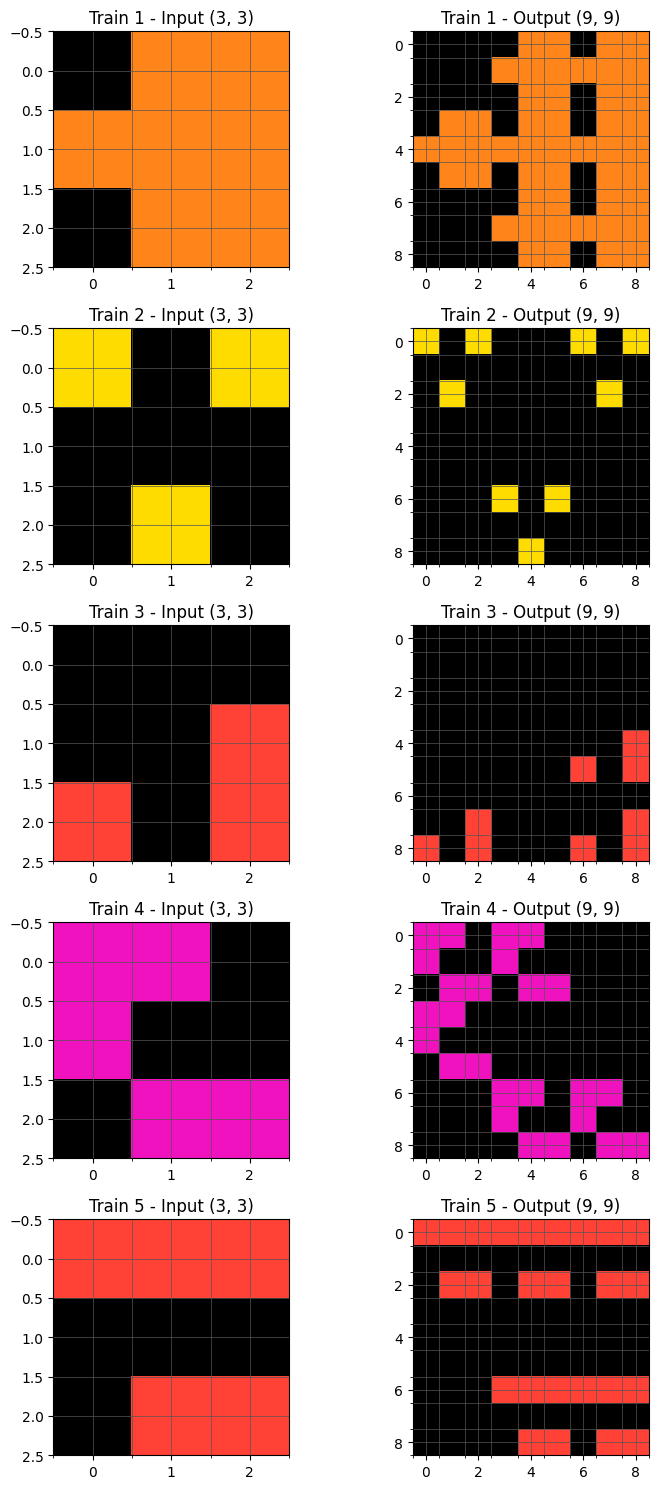

In [7]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

# 1. Clone the official ARC repository to fetch the clean JSON task data
if not os.path.exists('ARC'):
    print("Cloning official ARC repository...")
    !git clone https://github.com/fchollet/ARC.git
else:
    print("ARC repository already exists.")

# 2. Define standard ARC 10-color palette for professional visualization
arc_colors = [
    '#000000', '#0074D9', '#FF4136', '#2ECC40', '#FFDC00',
    '#AAAAAA', '#F012BE', '#FF851B', '#7FDBFF', '#870000'
]
cmap = colors.ListedColormap(arc_colors)
norm = colors.Normalize(vmin=0, vmax=9)

# 3. Setup paths for the training dataset
training_path = 'ARC/data/training/'
task_files = sorted(os.listdir(training_path))
print(f"Successfully located {len(task_files)} valid ARC task files.")

# 4. Load the first valid puzzle file to visualize the grids
sample_task_file = os.path.join(training_path, task_files[0])
print(f"Loading task file: {task_files[0]}")

with open(sample_task_file, 'r') as f:
    task = json.load(f)

# 5. Plot the 'train' input-output grid pairs
num_train = len(task['train'])
fig, axs = plt.subplots(num_train, 2, figsize=(8, num_train * 3))

# Handle single training pair edge case to keep axs indexable
if num_train == 1:
    axs = np.expand_dims(axs, axis=0)

for i, sample in enumerate(task['train']):
    # Process and plot Input Grid
    in_grid = np.array(sample['input'])
    axs[i, 0].imshow(in_grid, cmap=cmap, norm=norm)
    axs[i, 0].grid(True, which='both', color='#555555', linestyle='-', linewidth=0.5)
    axs[i, 0].set_title(f"Train {i+1} - Input {in_grid.shape}")
    axs[i, 0].set_xticks(np.arange(-.5, in_grid.shape[1], 1), minor=True)
    axs[i, 0].set_yticks(np.arange(-.5, in_grid.shape[0], 1), minor=True)

    # Process and plot Output Grid
    out_grid = np.array(sample['output'])
    axs[i, 1].imshow(out_grid, cmap=cmap, norm=norm)
    axs[i, 1].grid(True, which='both', color='#555555', linestyle='-', linewidth=0.5)
    axs[i, 1].set_title(f"Train {i+1} - Output {out_grid.shape}")
    axs[i, 1].set_xticks(np.arange(-.5, out_grid.shape[1], 1), minor=True)
    axs[i, 1].set_yticks(np.arange(-.5, out_grid.shape[0], 1), minor=True)

plt.tight_layout()
plt.show()